# What are Outliers

* { mean + Std  
 mean - Std }    = 68%

* {mean + 2*Std, 
mean - 2*Std }  = 95% of data
* {mean + 3*Std, 
mean - 3*Std }  = 99.7% of data

* remaining data will be outlier



## Z score:
* Xi' = (Xi - mean)/ std

## Treatment of Outliers
1. Trimming : remove outlier rows (only if less number of outlier)
2. Capping : ex. values lie btw [-3,3] then outlier 85 will be replaced by 3 and -9 will become -3.


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
df = pd.read_csv(r'c:\Users\rajku\Downloads\placement.csv')

In [15]:
df.sample(5)

,cgpa,placement_exam_marks,placed
587,7.58,14.0,1
329,7.30,35.0,0
765,6.55,28.0,0
485,4.92,44.0,1
457,6.58,20.0,0


C:\Users\rajku\AppData\Local\Temp\ipykernel_9892\3154593444.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['cgpa'])
C:\Users\rajku\AppData\Local\Temp\ipykernel_9892\3154593444.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])


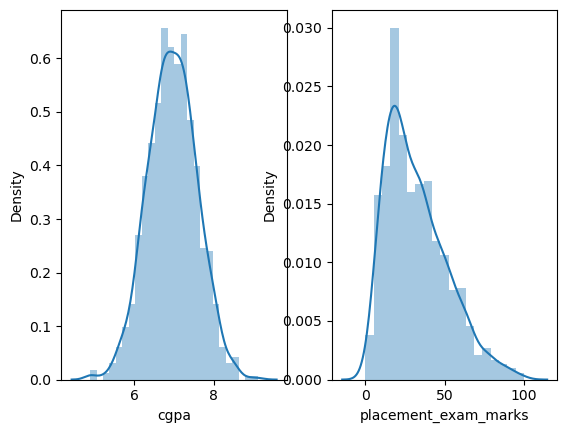

In [16]:
plt.Figure(figsize=(16,5))
plt.subplot(121)
sns.distplot(df['cgpa'])

plt.subplot(122)
sns.distplot(df['placement_exam_marks'])
plt.show()



In [17]:
print("mean ",df['cgpa'].mean())
print("Median",df['cgpa'].median())
print("Min ",df['cgpa'].min())
print("Max ",df['cgpa'].max())

mean  6.96124
Median 6.96
Min  4.89
Max  9.12


In [20]:
print("Maximum value of cgpa should exist is ",df['cgpa'].mean() + 3*df['cgpa'].std())
print("Minimum value of cgpa should exist is ",df['cgpa'].mean() - 3*df['cgpa'].std())

Maximum value of cgpa should exist is  8.808933625397168
Minimum value of cgpa should exist is  5.113546374602832


In [39]:
df[(df['cgpa'] > 8.808933625397) | (df['cgpa'] < 5.1135467)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


In [40]:
# Trimming
new_df = df[(df['cgpa'] < 8.8089) & (df['cgpa'] > 5.1135)]

In [25]:
print(new_df.sample(5))
print(new_df.shape)

     cgpa  placement_exam_marks  placed
240  7.25                  38.0       0
150  8.53                  22.0       0
115  7.28                  37.0       0
798  5.86                  56.0       0
533  7.19                  15.0       0
(995, 3)


In [45]:
# approach 2
df['cgpa_zscore'] = (df['cgpa'] - df['cgpa'].mean())/ df['cgpa'].std()

In [27]:
df.sample(10)

,cgpa,placement_exam_marks,placed,cgpa_zscore
961,7.65,9.0,0,1.118302
831,6.81,55.0,1,-0.245560
858,7.51,26.0,0,0.890992
142,7.66,41.0,1,1.134539
342,6.37,23.0,0,-0.959964
287,6.24,24.0,1,-1.171038
659,6.68,37.0,0,-0.456634
556,6.70,15.0,1,-0.424161
364,6.87,9.0,1,-0.148141
454,7.13,53.0,0,0.274006


In [47]:
df[(df['cgpa_zscore'] >3) | (df['cgpa_zscore'] <-3)]

,cgpa,placement_exam_marks,placed,cgpa_zscore
485,4.92,44.0,1,-3.314251
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [48]:
new_df2 = df[(df['cgpa_zscore'] <3) & (df['cgpa_zscore']>-3)]

In [49]:
new_df2[(new_df2['cgpa_zscore'] >3) | (new_df2['cgpa_zscore'] <-3)]

,cgpa,placement_exam_marks,placed,cgpa_zscore


# Capping method

In [50]:
upper_limit = df['cgpa'].mean() + 3*df['cgpa'].std()
lower_limit = df['cgpa'].mean() - 3*df['cgpa'].std()

In [52]:
lower_limit

np.float64(5.113546374602832)

In [53]:
df['cgpa'] = np.where(
    df['cgpa'] > upper_limit,
    upper_limit,
    
    np.where(df['cgpa'] < lower_limit,
    lower_limit,
    df['cgpa']
    )
)

In [57]:
df.sample(15)
df.shape
df.describe()

,cgpa,placement_exam_marks,placed,cgpa_zscore
count,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,6.961499,32.225000,0.489000,-1.474376e-16
std,0.612688,19.130822,0.500129,1.000000e+00
min,5.113546,0.000000,0.000000,-3.362960e+00
25%,6.550000,17.000000,0.000000,-6.677081e-01
50%,6.960000,28.000000,0.000000,-2.013321e-03
75%,7.370000,44.000000,1.000000,6.636815e-01
max,8.808934,100.000000,1.000000,3.505062e+00
